In [2]:
# ==========================================
# 1. CONECTAR GOOGLE DRIVE
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

# ==========================================
# 1. IMPORTS
# ==========================================
import os
import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from PIL import Image


# ==========================================
# 3. DEFINIR RUTAS Y CONSTANTES
# ==========================================
CSV_PATH     = "/content/drive/MyDrive/MachineLearning/Part3/CHEXNET/archive (Unzipped Files)/sample_labels.csv"
IMAGES_DIR   = "/content/drive/MyDrive/MachineLearning/Part3/CHEXNET/archive (Unzipped Files)/images"
MODEL_PATH   = "/content/drive/MyDrive/MachineLearning/Part3/CHEXNET/archive (Unzipped Files)/m-30012020-104001.pth"

# Las 14 patologías estándar de CheXNet
CLASS_NAMES = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia',
               'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']



Mounted at /content/drive


In [3]:
# ==========================================
# 4. DEFINIR LA ARQUITECTURA DEL MODELO
# ==========================================
class DenseNet121(nn.Module):

    def __init__(self, classCount, isTrained):

        super(DenseNet121, self).__init__()

        self.densenet121 = torchvision.models.densenet121(pretrained=isTrained)

        kernelCount = self.densenet121.classifier.in_features

        self.densenet121.classifier = nn.Sequential(nn.Linear(kernelCount, classCount), nn.Sigmoid())

    def forward(self, x):
        x = self.densenet121(x)
        return x

# ==========================================
class ChestXRayDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None, max_images=None):
        self.df = pd.read_csv(csv_file)
        if max_images is not None:
            self.df = self.df.iloc[:max_images]
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = str(self.df.iloc[idx, 0])
        labels = str(self.df.iloc[idx, 1])  # etiquetas como string
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name, labels

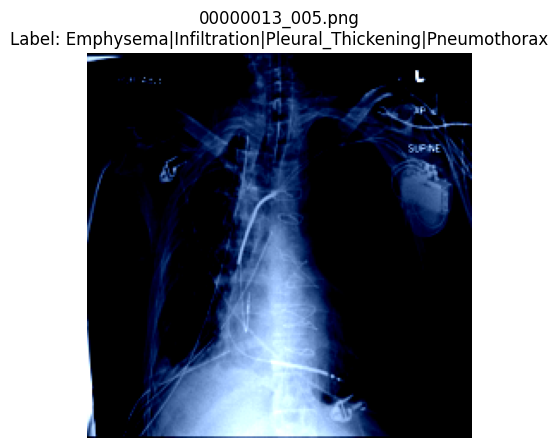

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
dataset=ChestXRayDataset(CSV_PATH, IMAGES_DIR,transform=transform)
image, name, label = dataset[0]  # puedes cambiar el índice

# Convertir tensor a formato visualizable
image_np = image.permute(1, 2, 0).numpy()

plt.figure(figsize=(5,5))
plt.imshow(image_np)
plt.title(f"{name}\nLabel: {label}")
plt.axis("off")
plt.show()


In [5]:

# ==========================================
# 4. CHEXNETTRAINER SOLO PARA TEST/INFERENCIA
# ==========================================
class ChexnetTrainer:

    CLASS_NAMES = [
        'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule',
        'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema',
        'Fibrosis', 'Pleural_Thickening', 'Hernia'
    ]

    @staticmethod
    def computeAUROC(dataGT, dataPRED, classCount):
        outAUROC = []
        datanpGT = dataGT.cpu().numpy()
        datanpPRED = dataPRED.cpu().numpy()
        for i in range(classCount):
            try:
                outAUROC.append(roc_auc_score(datanpGT[:, i], datanpPRED[:, i]))
            except ValueError:
                # En caso de que una clase no esté presente en el subset
                outAUROC.append(np.nan)
        return outAUROC

    @staticmethod
    def test(csv_file, image_dir, model_path, nnClassCount=14, nnIsTrained=True,
             trBatchSize=32, transResize=256, transCrop=224, max_images=None):

        cudnn.benchmark = True
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # -------------------- Modelo
        model = DenseNet121(nnClassCount, isTrained=nnIsTrained)
        checkpoint = torch.load(model_path, map_location=device)
        if 'state_dict' in checkpoint:
            model.load_state_dict(checkpoint['state_dict'])
        else:
            model.load_state_dict(checkpoint)
        model.to(device)
        model.eval()

        # -------------------- Transformaciones
        transform = transforms.Compose([
            transforms.Resize(transResize),
            transforms.CenterCrop(transCrop),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

        # -------------------- Dataset y DataLoader
        dataset = ChestXRayDataset(csv_file=csv_file, image_dir=image_dir,
                                   transform=transform, max_images=max_images)
        loader = DataLoader(dataset, batch_size=trBatchSize, shuffle=False, num_workers=4)

        # -------------------- Inferencia
        all_outputs = []
        all_labels = []
        all_names = []

        with torch.no_grad():
            for images, names, labels in loader:
                images = images.to(device)
                outputs = model(images)
                all_outputs.append(outputs.cpu())
                all_names.extend(names)
                all_labels.extend(labels)

        all_outputs = torch.cat(all_outputs, dim=0).numpy()

        # Convertir etiquetas reales a formato binario para AUROC
        # Asume etiquetas separadas por "|"
        y_true = np.zeros((len(all_labels), nnClassCount))
        class_to_idx = {c:i for i,c in enumerate(ChexnetTrainer.CLASS_NAMES)}
        for i, label_str in enumerate(all_labels):
            for lbl in label_str.split('|'):
                if lbl in class_to_idx:
                    y_true[i, class_to_idx[lbl]] = 1
        y_true = torch.FloatTensor(y_true)

        # -------------------- AUROC
        aurocIndividual = ChexnetTrainer.computeAUROC(y_true, torch.FloatTensor(all_outputs), nnClassCount)
        aurocMean = np.nanmean(aurocIndividual)
        print("AUROC mean:", aurocMean)
        for i, auc in enumerate(aurocIndividual):
            print(ChexnetTrainer.CLASS_NAMES[i], auc)

        return all_names, y_true, all_outputs

# ==========================================
# 5. FUNCION PARA PLOTEAR ROC POR CLASE
# ==========================================
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(y_true, y_pred, class_names):
    plt.figure(figsize=(12, 10))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')
    plt.plot([0,1], [0,1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves per Class')
    plt.legend(loc='lower right', fontsize='small')
    plt.show()
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def show_image_predictions(image_path, labels_true, y_pred_probs, class_names, threshold=0.5):
    """
    image_path: ruta a la imagen
    labels_true: vector binario real
    y_pred_probs: vector de probabilidades predichas por CheXNet
    class_names: lista de 14 patologías
    threshold: a partir de qué probabilidad consideramos que la clase está presente
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from PIL import Image

    # Convertir probabilidades a predicción binaria
    y_pred_bin = (y_pred_probs >= threshold).astype(int)

    # Mostrar imagen
    img = Image.open(image_path).convert('RGB')
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Etiquetas reales: {', '.join([c for i,c in enumerate(class_names) if labels_true[i]==1])}\n"
              f"Predicción: {', '.join([c for i,c in enumerate(class_names) if y_pred_bin[i]==1])}")
    plt.show()

    # Matriz de confusión por clase
    print("\nMatriz de confusión por clase (positivo=presente, negativo=ausente)")
    for i, cls in enumerate(class_names):
        cm = confusion_matrix([labels_true[i]], [y_pred_bin[i]], labels=[0,1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'No {cls}', cls])
        print(f"\nClase: {cls}")
        disp.plot(cmap=plt.cm.Blues)
        plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 216MB/s]


AUROC mean: 0.5663737325617291
Atelectasis 0.8498121851088738
Cardiomegaly 0.9483599696326721
Effusion 0.7048249929276164
Infiltration 0.6550508224301274
Mass 0.5719217597959043
Nodule 0.49920535229783874
Pneumonia 0.38707059069962296
Pneumothorax 0.4424139827152723
Consolidation 0.5251776491101096
Edema 0.3673870880071157
Emphysema 0.34210076268300005
Fibrosis 0.7841275590279574
Pleural_Thickening 0.43410084965678886
Hernia 0.4176786917713075


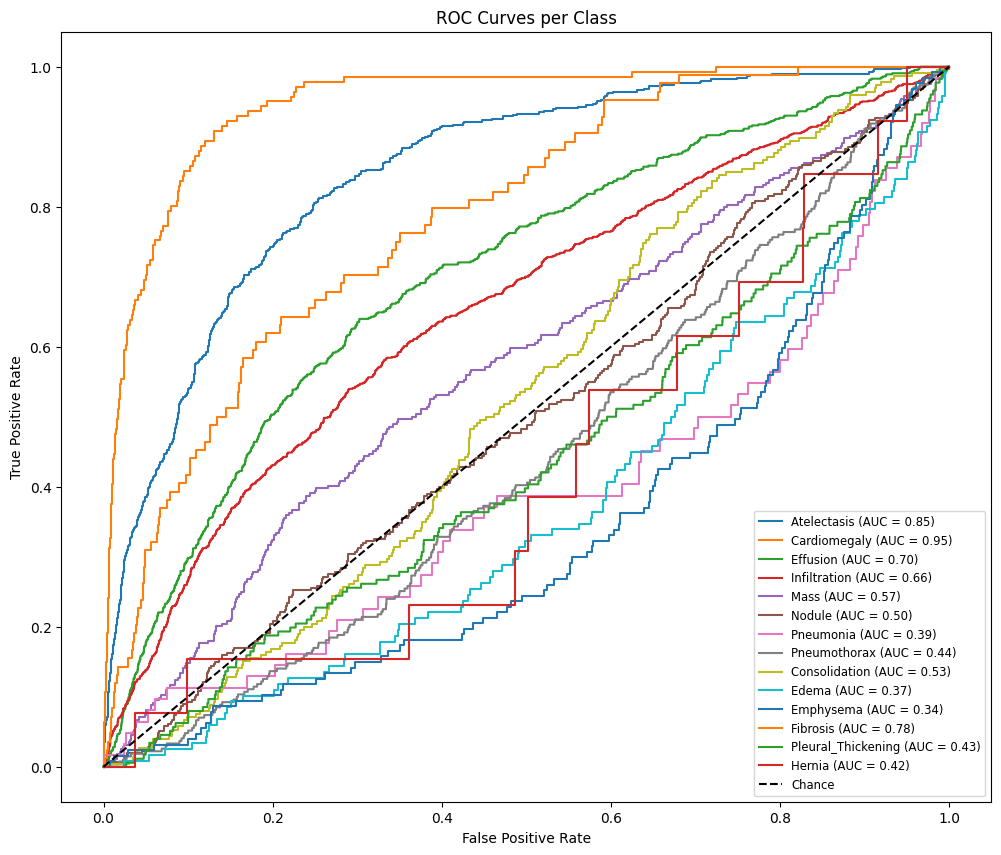

In [6]:


# Inferencia
names, y_true, y_pred = ChexnetTrainer.test(
    csv_file=CSV_PATH,
    image_dir=IMAGES_DIR,
    model_path=MODEL_PATH,
    nnClassCount=14,
    nnIsTrained=True,
    trBatchSize=32,
    transResize=256,
    transCrop=224,
    max_images=None
)

# Plot ROC por clase
plot_roc_curves(y_true.numpy(), y_pred, ChexnetTrainer.CLASS_NAMES)

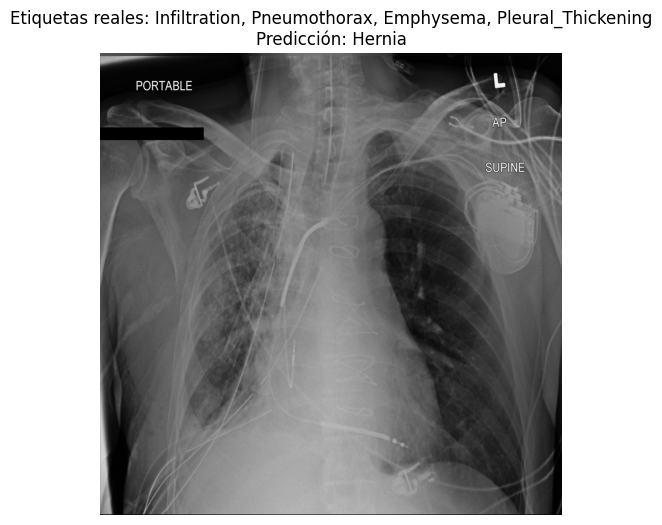


Matriz de confusión por clase (positivo=presente, negativo=ausente)

Clase: Atelectasis


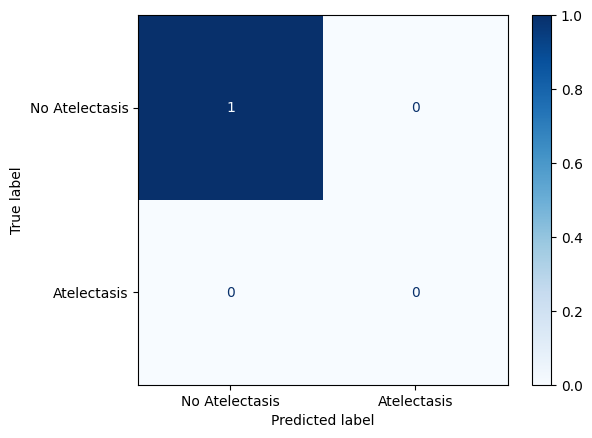


Clase: Cardiomegaly


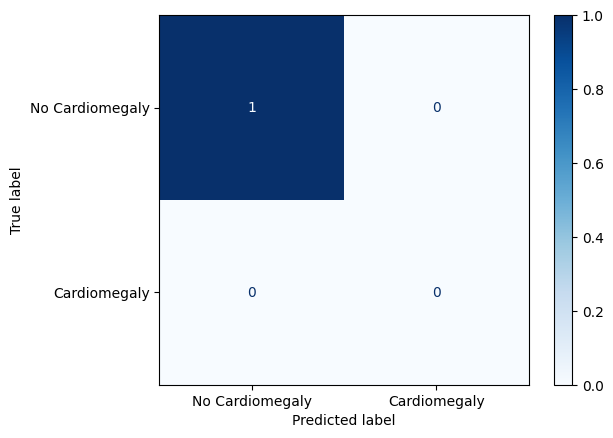


Clase: Effusion


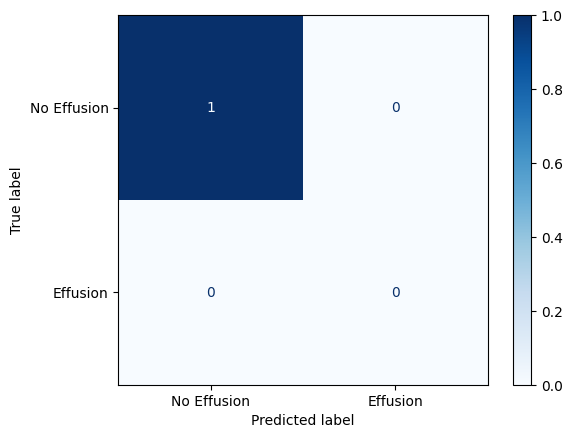


Clase: Infiltration


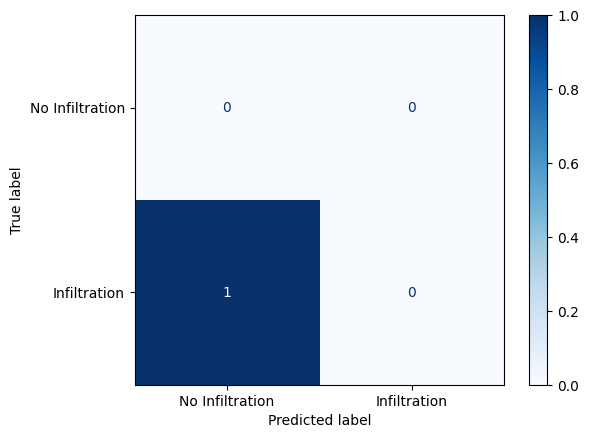


Clase: Mass


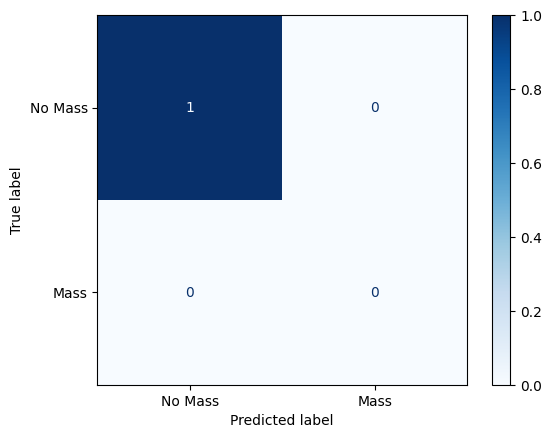


Clase: Nodule


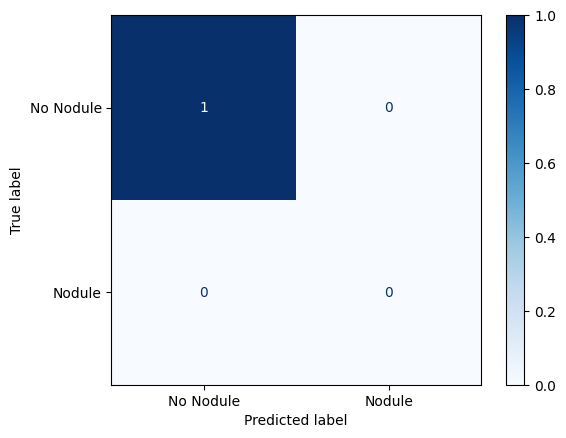


Clase: Pneumonia


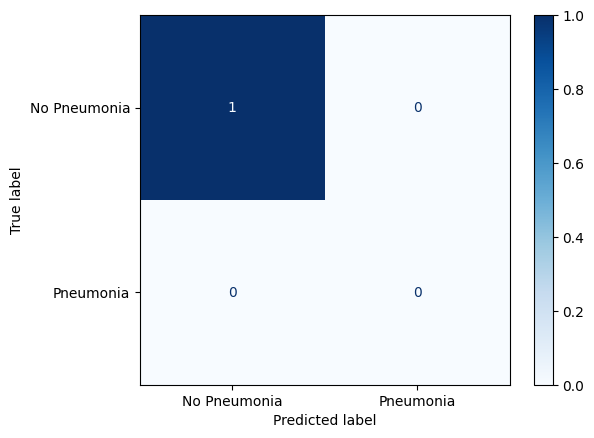


Clase: Pneumothorax


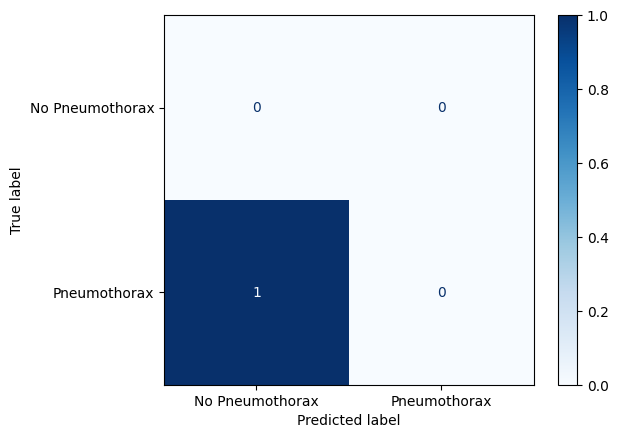


Clase: Consolidation


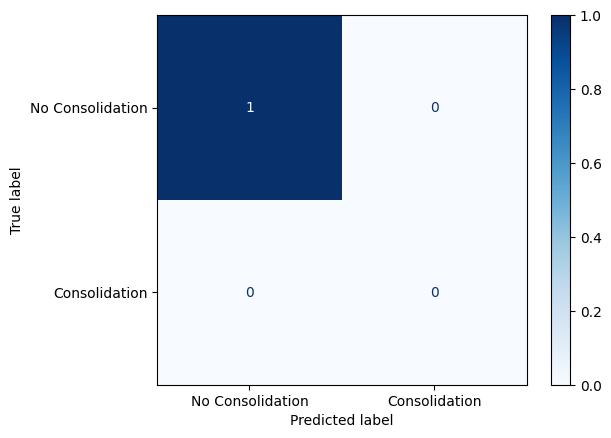


Clase: Edema


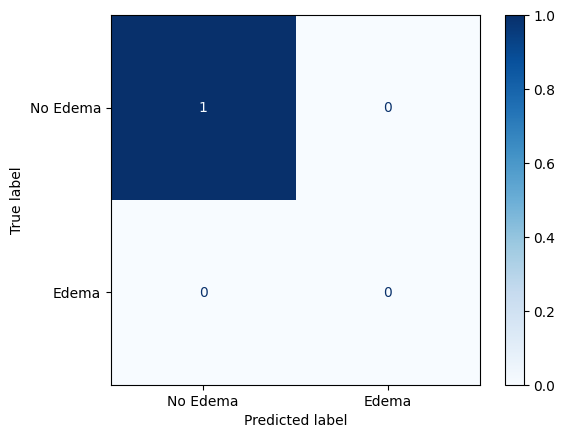


Clase: Emphysema


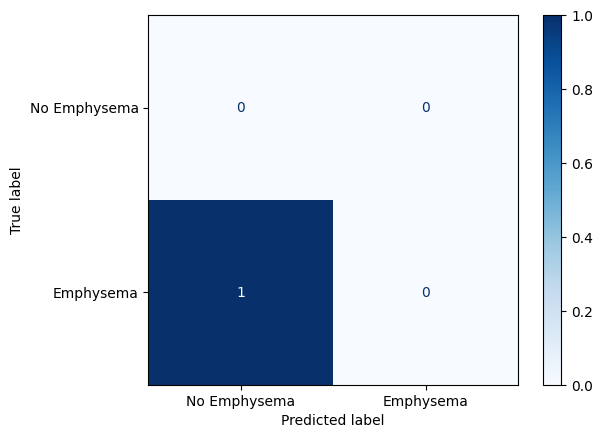


Clase: Fibrosis


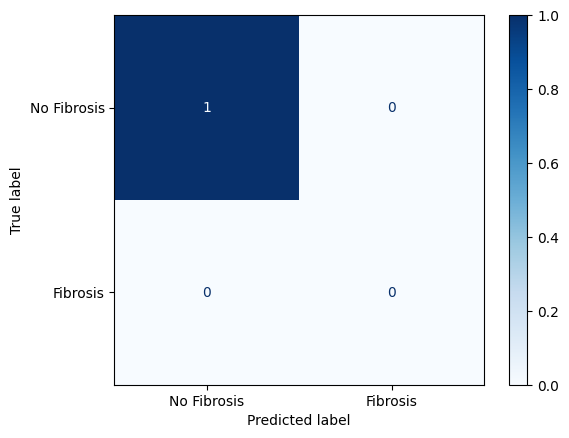


Clase: Pleural_Thickening


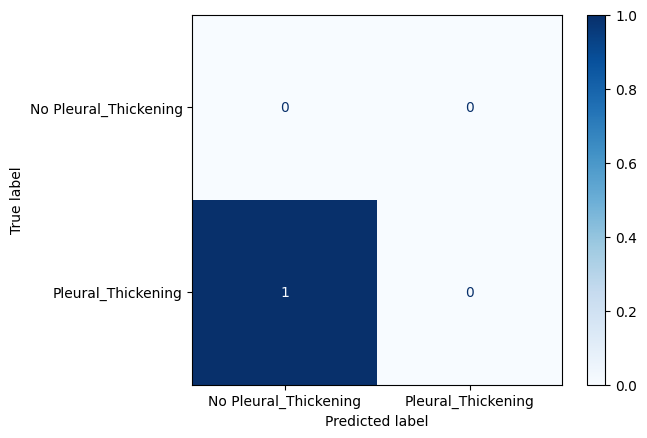


Clase: Hernia


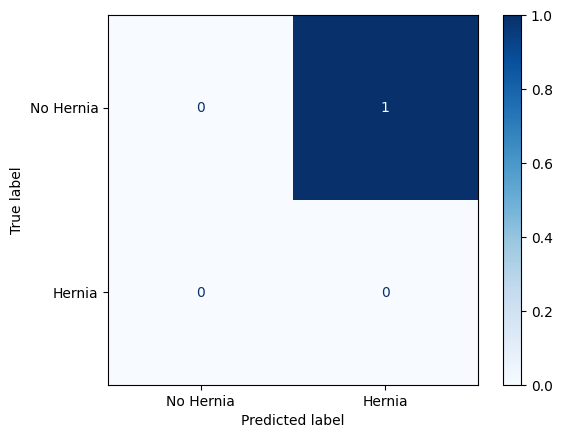

In [ ]:
idx = 0  # índice de la imagen
show_image_predictions(
    image_path=os.path.join(IMAGES_DIR, names[idx]),
    labels_true=y_true[idx].numpy(),
    y_pred_probs=y_pred[idx],
    class_names=ChexnetTrainer.CLASS_NAMES,
    threshold=0.5
)